In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression


In [5]:
df=pd.read_csv("/content/insurance (2).csv")

In [6]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


/tmp/ipykernel_6959/3608791066.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


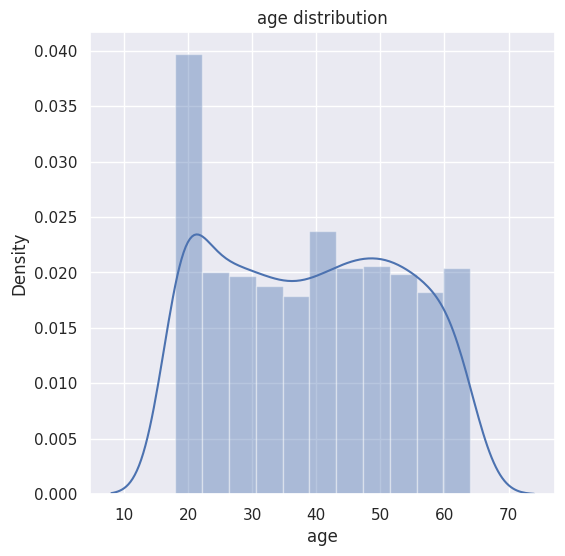

In [10]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(df['age'])
plt.title("age distribution")
plt.show()


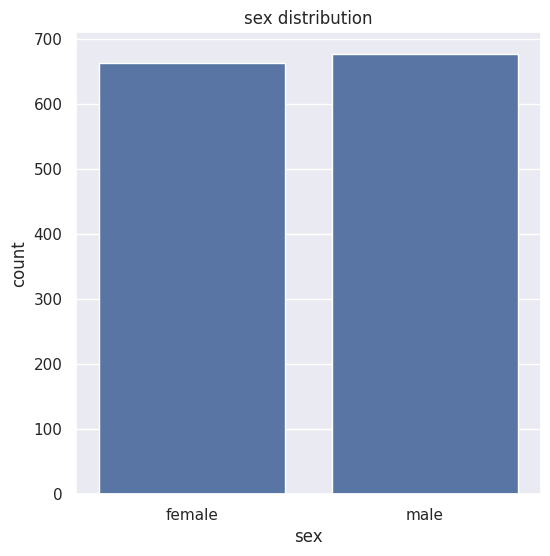

In [11]:
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data=df)
plt.title("sex distribution")
plt.show()

In [12]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipykernel_6959/1190753365.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


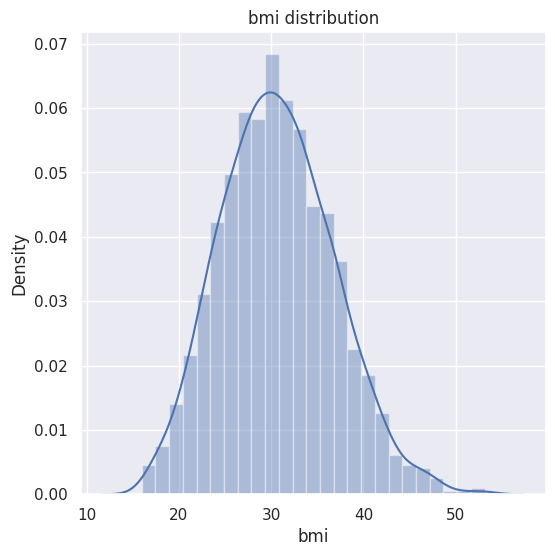

In [13]:
plt.figure(figsize=(6,6))
sns.distplot(df['bmi'])
plt.title("bmi distribution")
plt.show()

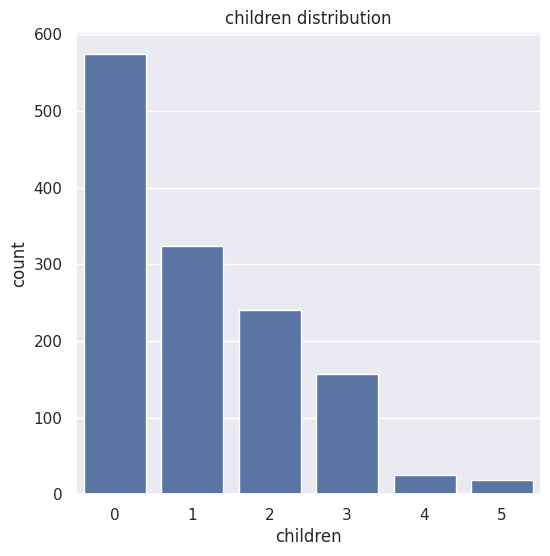

In [14]:
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=df)
plt.title("children distribution")
plt.show()

In [15]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


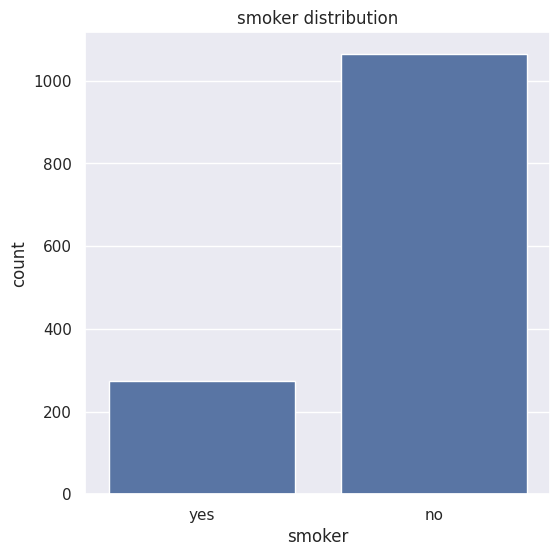

In [16]:
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=df)
plt.title("smoker distribution")
plt.show()

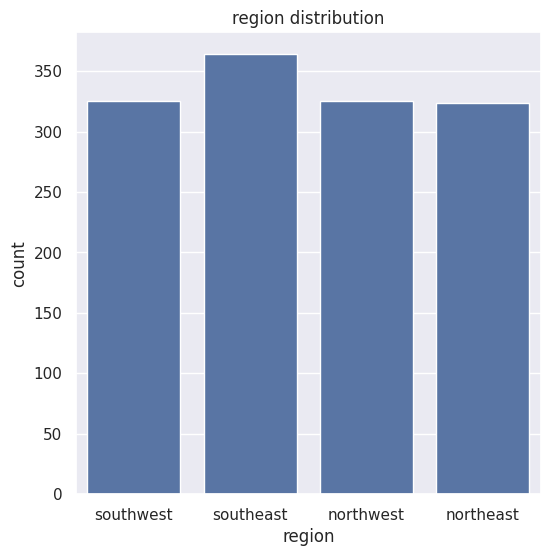

In [17]:
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=df)
plt.title("region distribution")
plt.show()

/tmp/ipykernel_6959/2191683745.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


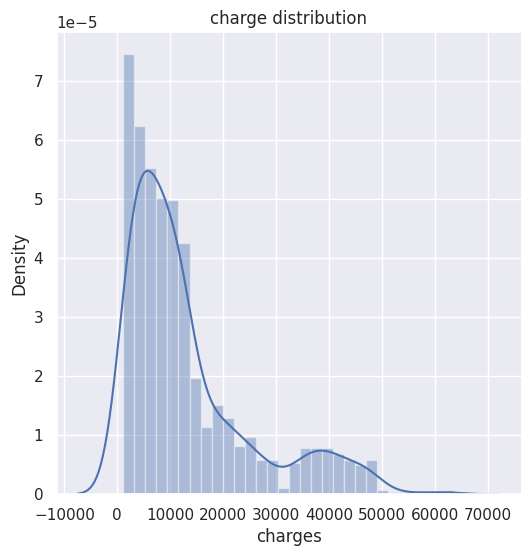

In [18]:
plt.figure(figsize=(6,6))
sns.distplot(df['charges'])
plt.title("charge distribution")
plt.show()

In [19]:
#encoding the sex column
df.replace({'sex':{'male':0,'female':1}},inplace=True)
#encoding the smoker column
df.replace({'smoker':{'yes':0,'no':1}},inplace=True)
#encoding the region column
df.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)


/tmp/ipykernel_6959/3151712748.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'sex':{'male':0,'female':1}},inplace=True)
/tmp/ipykernel_6959/3151712748.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'smoker':{'yes':0,'no':1}},inplace=True)
/tmp/ipykernel_6959/3151712748.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd

In [20]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


In [24]:
#splitting the features and the targets
X=df.drop(columns='charges',axis=1)
Y=df['charges']

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [28]:
#model training
model=LinearRegression()

In [29]:
model.fit(X_train,y_train)

LinearRegression()

In [30]:
x_pred=model.predict(X_test)

In [34]:
acc=r2_score(y_test,x_pred)

In [35]:
print(acc)

0.7447273869684076


In [37]:
#building a predictive system
imput_data=(33,	0,	22.705,	0,	1,	3)
#changing the input data to a numpy array
input_data_as_numpy_array=np.asarray(imput_data)
#reshape the array
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=model.predict(input_data_reshaped)
print(prediction)

[3869.92920489]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
